## ***NHẬT KÝ THỰC HÀNH***
### **Mục tiêu bài toán là dự đoán loài hoa dựa trên 4 đặc trưng số**
+ Đây là bài toán phân loại đa lớp (multiclass classification)
+ 17/10 Thử nghiệm trên nhiều mô hình khác nhau.

## **Phục hồi dữ liệu**

In [59]:
import numpy as np
import pandas as pd
import joblib

save_dir = "exp"

# 1️⃣ Đọc lại file data.npz
data = np.load(f'{save_dir}/data.npz')

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print("✅ Phục hồi dữ liệu huấn luyện / kiểm thử:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

# 2️⃣ Đọc lại DataFrame đã làm sạch
df_clean = pd.read_csv(f'{save_dir}/df_clean.csv')
print("\n✅ Đọc lại df_clean.csv thành công")
print(df_clean.head())

# 3️⃣ Đọc lại class encoder
class_encoder = joblib.load(f'{save_dir}/class_encoder.joblib')
print("\n✅ Phục hồi class_encoder thành công")

# (Tuỳ chọn) Kiểm tra nhãn
print("Các lớp trong encoder:", list(class_encoder.classes_))


✅ Phục hồi dữ liệu huấn luyện / kiểm thử:
X_train shape: (102, 4)
X_test shape : (45, 4)

✅ Đọc lại df_clean.csv thành công
   sepal-length  sepal-width  petal-length  petal-width  class
0           5.1          3.5           1.4          0.2      0
1           4.9          3.0           1.4          0.2      0
2           4.7          3.2           1.3          0.2      0
3           4.6          3.1           1.5          0.2      0
4           5.0          3.6           1.4          0.2      0

✅ Phục hồi class_encoder thành công
Các lớp trong encoder: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [60]:
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
#from pandas.tools.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Khai báo thư viện cho mô hình phân loại đa lớp
from sklearn.linear_model import LogisticRegression# Mô hình tuyến tính
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis# Phân tích tuyến tính
from sklearn.tree import DecisionTreeClassifier# Cây quyết định
from sklearn.neighbors import KNeighborsClassifier# Mô hình khoảng cách (k-láng giềng)
from sklearn.svm import SVC# Mô hình SVM (máy vector hỗ trợ)
from sklearn.naive_bayes import GaussianNB# Mô hình xác suất
from sklearn.neural_network import MLPClassifier# Mạng nơ-ron đơn giản (đa lớp)
from sklearn.ensemble import RandomForestClassifier#rừng ngẫu nhiên
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error

### **Evaluate Algorithms: Baseline**

In [61]:
 # Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'accuracy'

In [62]:
 # Spot-Check Algorithms
models = []
models.append(('LOGR', LogisticRegression(max_iter=1000, random_state=42)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('GNB', GaussianNB()))
models.append(('NEU', MLPClassifier(max_iter=1000, random_state=42)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVC', SVC(max_iter=1000, random_state=42)))
models.append(('RF', RandomForestClassifier()))

In [63]:
 # evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LOGR: 0.960000 (0.048990)
LDA: 0.960909 (0.047941)
GNB: 0.930909 (0.089738)
NEU: 0.960909 (0.047941)
KNN: 0.950909 (0.066457)
CART: 0.930909 (0.089738)
SVC: 0.950000 (0.067082)
RF: 0.930909 (0.063662)


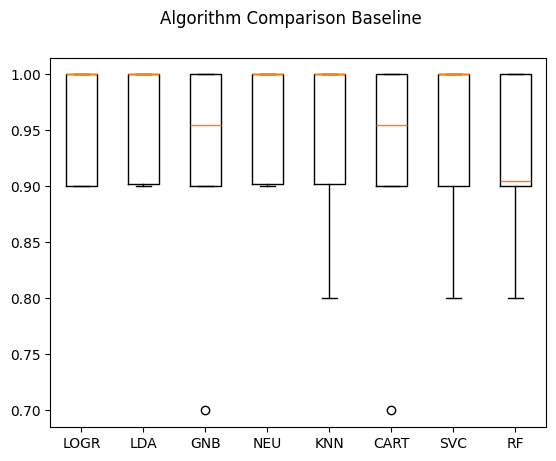

In [64]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison Baseline')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

### **Evaluate Algorithms: Standardization**

In [65]:
# Standardize the dataset
pipelines = []
pipelines.append(('ScaledLOGR', Pipeline([('Scaler', StandardScaler()),('LOGR',
    LogisticRegression(max_iter=1000, random_state=42))])))
pipelines.append(('ScaledLDA', Pipeline([('Scaler', StandardScaler()),('LDA',
    LinearDiscriminantAnalysis())])))
pipelines.append(('ScaledGNB', Pipeline([('Scaler', StandardScaler()),('GNB',
    GaussianNB())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN',
    KNeighborsClassifier())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART',
    DecisionTreeClassifier())])))
pipelines.append(('ScaledSVC', Pipeline([('Scaler', StandardScaler()),('SVC', 
    SVC(max_iter=1000, random_state=42))])))
pipelines.append(('ScaledNEU', Pipeline([('Scaler', StandardScaler()),('NEU', 
    MLPClassifier(max_iter=1000, random_state=42))])))
pipelines.append(('ScaledRF', Pipeline([('Scaler', StandardScaler()),('RF', 
    RandomForestClassifier())])))
results = []
names = []
for name, model in pipelines:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

ScaledLOGR: 0.940909 (0.048319)
ScaledLDA: 0.960909 (0.047941)
ScaledGNB: 0.930909 (0.089738)
ScaledKNN: 0.940909 (0.048319)
ScaledCART: 0.940909 (0.065839)
ScaledSVC: 0.940909 (0.048319)
ScaledNEU: 0.930909 (0.063662)
ScaledRF: 0.940909 (0.065839)


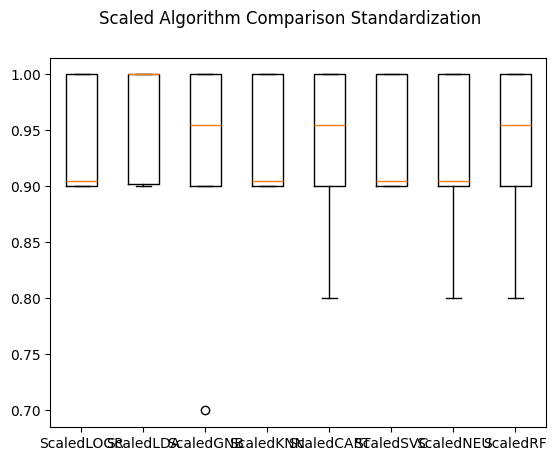

In [66]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison Standardization')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()